## Bias Varience Trade-off:
The bias-variance tradeoff is a balancing act in machine learning between a model being too simple (high bias) and too complex (high variance). The goal is to minimize total prediction error so the model can accurately generalize to new, unseen data.

**Bias:** <br>
The error caused by overly simplistic assumptions in the learning algorithm. 
    
- High bias makes a model rigid, leading it to miss relevant patterns and underfit the data.


**Variance:** <br>
The error caused by the model being too sensitive to small fluctuations or noise in the training dataset. 

- High variance means the model is overly complex and memorizes training data (including random noise) rather than learning true trends, leading to overfitting.

#### Methods for Bias Varience Trade-off:
- Regularization
- Bagging
- Boosting 

## Regularization 

**Ridge Regression:** is just a modified version of ordinary linear regression. It includes a built-in safety mechanism designed to stop your model from overfitting—meaning it keeps the model from memorizing your training data too closely and failing when it meets new, unseen data.

### Ridge Regression apply in demo data 

In [1]:
from sklearn.datasets import make_regression 
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
x,y = make_regression(n_samples = 100, n_features = 1, n_informative=1, n_targets=1, noise=20, random_state=13)

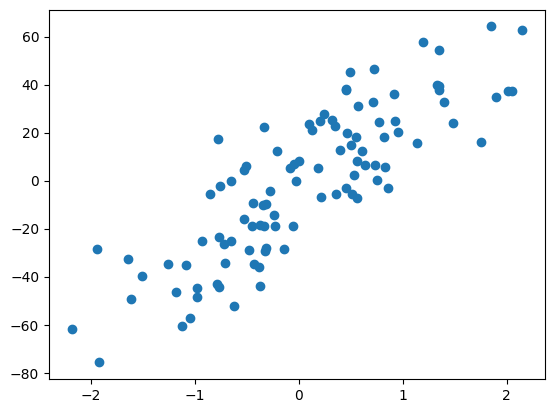

In [4]:
plt.scatter(x,y)

In [5]:
from sklearn.linear_model import LinearRegression

In [42]:
lr = LinearRegression()
lr.fit(x_train,y_train)
print(lr.coef_)
print(lr.intercept_)

[28.67684216]
-2.088699766134101


In [7]:
from sklearn.linear_model import Ridge

In [43]:
rr = Ridge(alpha = 10)
rr.fit(x_train,y_train)
print(rr.coef_)
print(rr.intercept_)

[24.82106414]
-2.2985097444611213


In [54]:
rr_predict = rr.predict(x_test)
rr_predict

array([ 30.72137194,  44.68136626,  18.32545288, -21.37665033,
         8.91595329, -12.96901279,  27.25606219,  16.71221753,
        -5.90280954,  -4.32518826, -33.61291183,  11.30140576,
         2.85930871,  48.67634179,  -2.3578079 ,  51.07628381,
        10.91468312, -15.28400228,  34.40404378,  -2.96301059])

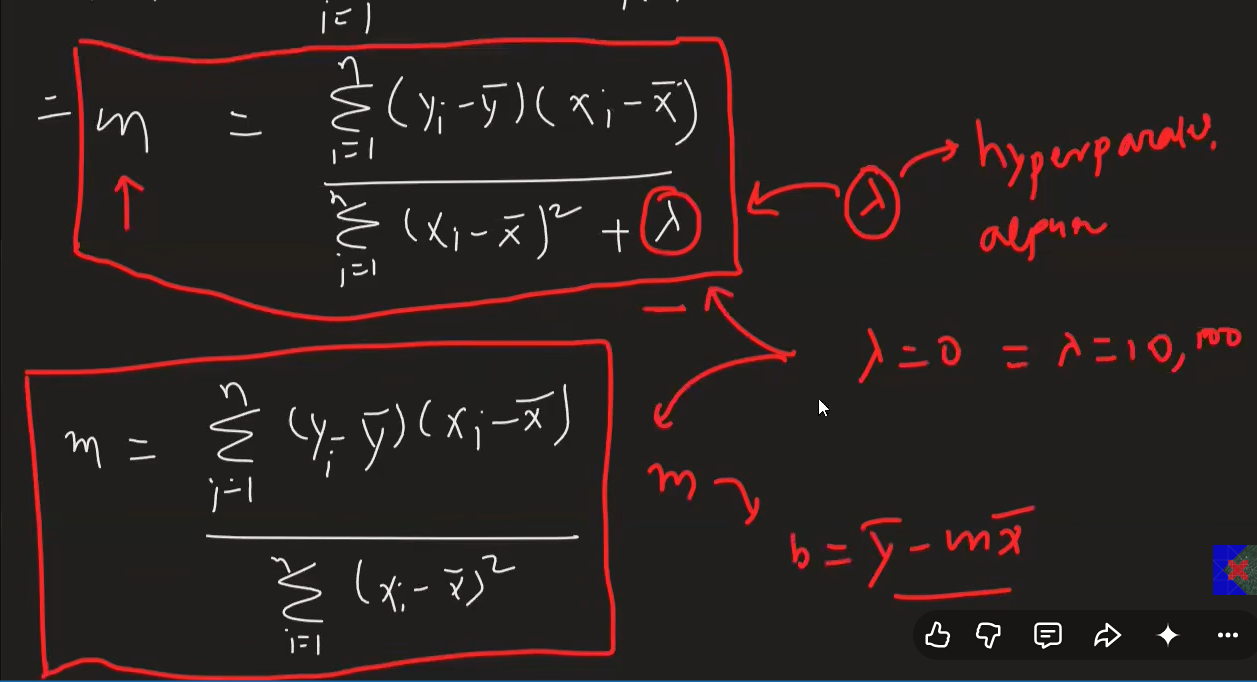

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 13)

## Create python class for Ridge Regression

In [62]:
class RidgeRegression:
    def __init__(self, alpha = 0.1):
        self.alpha = alpha
        self.m = None
        self.b = None

    def fit(self,x_train, y_train):
        num = 0 
        den = 0
        
        for i in range(x_train.shape[0]):
            num = num + ((y_train[i] - y_train.mean())*(x_train[i] - x_train.mean()))
            den =den + (x_train[i] - x_train.mean()) * (x_train[i] - x_train.mean())

        self.m = num /( den + self.alpha)
        self.b = (y_train.mean() - (self.m* x_train.mean()))
        print(self.m, self.b)
    def pred(self,x):
        y_predict = self.m *x + self.b
        print(y_predict)

In [63]:
reg = RidgeRegression(alpha = 10)

In [64]:
reg.fit(x_train, y_train)

[24.82106414] [-2.29850974]


In [65]:
reg.pred(x_test)

[[ 30.72137194]
 [ 44.68136626]
 [ 18.32545288]
 [-21.37665033]
 [  8.91595329]
 [-12.96901279]
 [ 27.25606219]
 [ 16.71221753]
 [ -5.90280954]
 [ -4.32518826]
 [-33.61291183]
 [ 11.30140576]
 [  2.85930871]
 [ 48.67634179]
 [ -2.3578079 ]
 [ 51.07628381]
 [ 10.91468312]
 [-15.28400228]
 [ 34.40404378]
 [ -2.96301059]]
